**Programmer:** python_scripts (Abhijith Warrier)

**PYTHON SCRIPT TO _COMPARE TWO MACHINE LEARNING MODELS USING A/B TESTING PRINCIPLES_. ⚡️🧪📊**

This script demonstrates how ML teams evaluate a new model against an existing production model before deployment.

We’ll compare:

- **Model A** → Current production model
- **Model B** → New candidate model

and determine which performs better based on business-relevant metrics.

---

## **📦 Import Required Libraries**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

---

## **🧩 Load Dataset**

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = data.target

---

## **✂️ Split Dataset**

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

---

## **🤖 Train Model A**

Current production model.

In [4]:
model_a = LogisticRegression(
    max_iter=5000
)

model_a.fit(
    X_train,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


---

## **🚀 Train Model B**

Candidate model.

In [5]:
model_b = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model_b.fit(
    X_train,
    y_train
)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


---

## **📊 Generate Predictions**

In [6]:
pred_a = model_a.predict(X_test)

pred_b = model_b.predict(X_test)

---

## **📈 Compare Metrics**

In [7]:
results = pd.DataFrame({
    "Model": [
        "Model A",
        "Model B"
    ],

    "Accuracy": [
        accuracy_score(y_test, pred_a),
        accuracy_score(y_test, pred_b)
    ],

    "Precision": [
        precision_score(y_test, pred_a),
        precision_score(y_test, pred_b)
    ],

    "Recall": [
        recall_score(y_test, pred_a),
        recall_score(y_test, pred_b)
    ],

    "F1 Score": [
        f1_score(y_test, pred_a),
        f1_score(y_test, pred_b)
    ]
})

print(results)

     Model  Accuracy  Precision    Recall  F1 Score
0  Model A  0.947368   0.937500  0.981308  0.958904
1  Model B  0.941520   0.944954  0.962617  0.953704


---

## **📊 Visualize A/B Results**

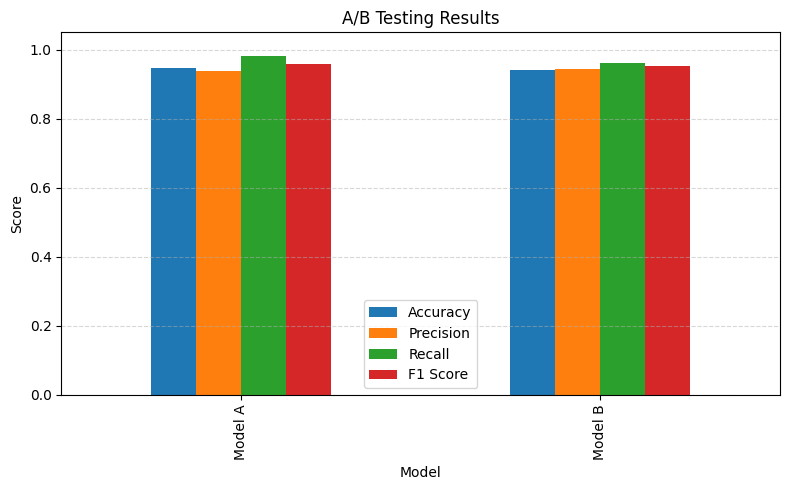

In [8]:
results.set_index("Model").plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("A/B Testing Results")
plt.ylabel("Score")
plt.ylim(0, 1.05)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()
plt.show()

---

## **🏆 Select Winner**

In [9]:
winner = results.loc[
    results["F1 Score"].idxmax(),
    "Model"
]

print(
    "Winning Model:",
    winner
)

Winning Model: Model A


---

## **🔍 Why A/B Testing Matters**

A/B testing helps teams:

- reduce deployment risk
- validate model improvements
- compare models fairly
- prevent performance regressions
- make evidence-based decisions

---

## **🧠 Real-World Example**

Instead of sending all traffic to a new model:
100% → New Model ❌

Organizations often use:

90% → Current Model

10% → Candidate Model

or

50% → Model A

50% → Model B

to compare performance safely.

---

## **🧠 Key Takeaways**

1. A/B testing compares production and candidate models.
2. Multiple metrics should be evaluated together.
3. F1-score often provides a balanced comparison.
4. A/B testing reduces deployment risk.
5. It is a common practice in production ML systems.

---

## **Conclusion**

A/B testing is one of the safest ways to introduce new machine learning models into production. By comparing candidate models against existing systems using controlled experiments, teams can confidently deploy improvements while minimizing risk.

---